# BCECF pH Calibration Analysis

Build a 490/440 ratio calibration curve from endpoint data, then apply to kinetic time-series.

In [3]:
%load_ext autoreload
%autoreload 2

import ph_calibration as phc

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Part 1: Calibration Curve
### Load calibration data + platemap

In [4]:
# Load endpoint calibration data
cal_data = phc.load_biotek_endpoint("BCECF pH measurement Calibration.xlsx")

# Load platemap
platemap = phc.load_platemap("platemap.csv")

print(f"Loaded {len(cal_data)} wells from calibration file")
print(f"Platemap has {len(platemap)} entries")
cal_data.head()

Loaded 96 wells from calibration file
Platemap has 12 entries


,row,column,well,value_440,value_490
0,A,1,A1,3,1
1,A,2,A2,2,2
2,A,3,A3,2,0
3,A,4,A4,3,2
4,A,5,A5,2,1


### Calculate 490/440 ratio and merge with platemap

In [5]:
# Calculate 490/440 ratio
cal_data = phc.calculate_ratio(cal_data)

# Merge with platemap (keeps only calibration wells)
cal_merged = cal_data.merge(platemap, on="well")
cal_merged[["well", "pH", "value_440", "value_490", "ratio"]]

,well,pH,value_440,value_490,ratio
0,G3,6.0,139,164,1.179856
1,G4,6.5,135,586,4.340741
2,G5,7.0,113,567,5.017699
3,G6,7.5,130,802,6.169231
4,G7,8.0,94,591,6.287234
5,G8,8.5,115,1018,8.852174
6,H3,6.0,220,326,1.481818
7,H4,6.5,162,744,4.592593
8,H5,7.0,172,992,5.767442
9,H6,7.5,199,1350,6.783920


### Mean and standard deviation per pH

In [6]:
cal_stats = phc.calculate_stats(cal_merged, group_col="pH")
cal_stats

,pH,mean,std,count
0,6.0,1.330837,0.213519,2
1,6.5,4.466667,0.178086,2
2,7.0,5.392570,0.530148,2
3,7.5,6.476575,0.434651,2
4,8.0,6.910740,0.881771,2
5,8.5,9.009938,0.223112,2


### Linear regression + calibration plot

slope = 2.6750, intercept = -13.7955, R² = 0.9298


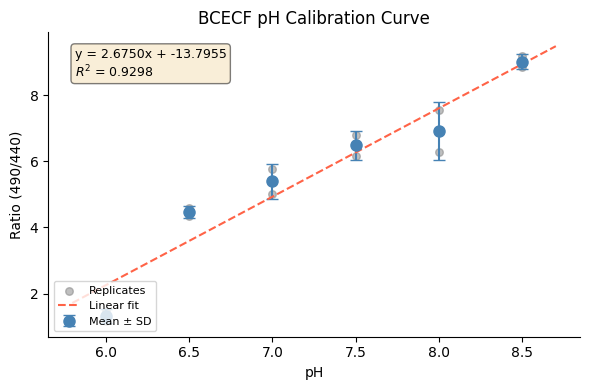

In [7]:
#| label: ph-callibration

fit = phc.fit_calibration(cal_stats)
print(f"slope = {fit.slope:.4f}, intercept = {fit.intercept:.4f}, R² = {fit.rvalue**2:.4f}")

phc.plot_calibration_curve(
    cal_stats, fit,
    individual_points=cal_merged[["pH", "ratio"]],
    ratio_label="490/440",
);

## Part 2: Apply calibration to kinetic data

In [9]:
# # Load kinetic data (only wells with signal)
# kinetic = phc.load_biotek_kinetic(
#     "BCECF pH measurement Data.xlsx",
#     wells=["C4", "C5", "D4", "D5", "E4", "E5"],
# )
# print(f"Loaded {len(kinetic)} data points across {kinetic['well'].nunique()} wells")
# kinetic.head()

# Load kinetic data (only wells with signal)
kinetic = phc.load_biotek_kinetic(
    "BCECF pH measurement Data 3_25_2026.xlsx",
    wells=["C4", "C5", "D4", "D5", "E4", "E5"],
)
print(f"Loaded {len(kinetic)} data points across {kinetic['well'].nunique()} wells")
kinetic.head()

# # Load kinetic data (only wells with signal)
# kinetic = phc.load_biotek_kinetic(
#     "BCECF pH measurement Data 6_5_2026.xlsx",
# )
print(f"Loaded {len(kinetic)} data points across {kinetic['well'].nunique()} wells")
kinetic.head()

Loaded 2790 data points across 6 wells
Loaded 2790 data points across 6 wells


,time_min,well,value_440,value_490
0,0.0,C4,4063,27344
1,3.0,C4,4066,26796
2,6.0,C4,4070,26230
3,9.0,C4,4042,25590
4,12.0,C4,4059,24921


In [10]:
# Calculate 490/440 ratio
kinetic = phc.calculate_ratio(kinetic)

## Part 3: Kinetic Analysis (sigmoid fit)

Fit a sigmoid_drift model to each well's pH time-series to extract:
- **Vmax**: Maximum rate of pH change (pH/hr)
- **Lag time**: Time before pH starts changing
- **Steady state**: Final pH level and time to reach 95% of asymptote
- **Drift**: Linear drift rate after sigmoid

In [11]:
# Fit sigmoid_drift to each well
kin = phc.fit_kinetics(kinetic, fit.slope, fit.intercept, fit_type="sigmoid_drift")
kin[["vmax", "vmax_time_hr", "lag_time_hr", "steady_state_pH", "steady_state_time_hr", "r_squared", "drift"]]

,vmax,vmax_time_hr,lag_time_hr,steady_state_pH,steady_state_time_hr,r_squared,drift
well,,,,,,,
C4,0.064854,4.168783,0.057640,7.959259,10.221288,0.985825,0.000864
C5,0.000000,0.000000,NaN,7.315730,0.059312,0.340863,-0.005547
D4,0.054584,4.527465,0.770210,7.907260,10.058968,0.986302,0.003786
D5,0.070522,4.924227,0.493633,8.053834,11.447034,0.989683,-0.000164
E4,0.057984,5.092224,1.293998,7.919606,10.684046,0.990213,0.006834
E5,0.065402,5.523260,0.889894,8.058981,12.344593,0.991435,0.001697


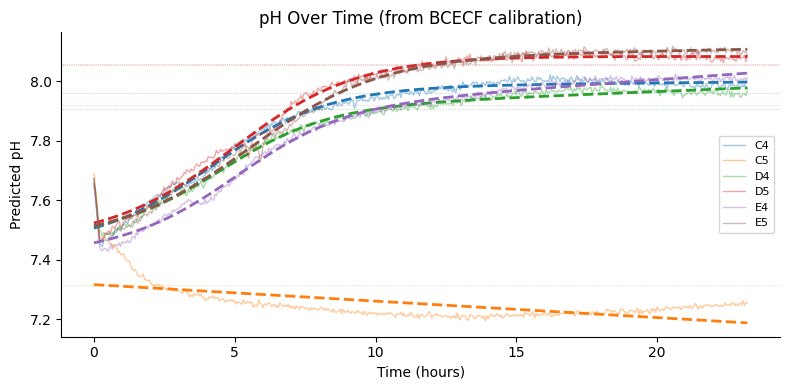

In [12]:
#| label: pH-vs-time

# pH over time with sigmoid fit overlay
phc.plot_kinetic_pH(kinetic, fit.slope, fit.intercept, kinetics=kin);

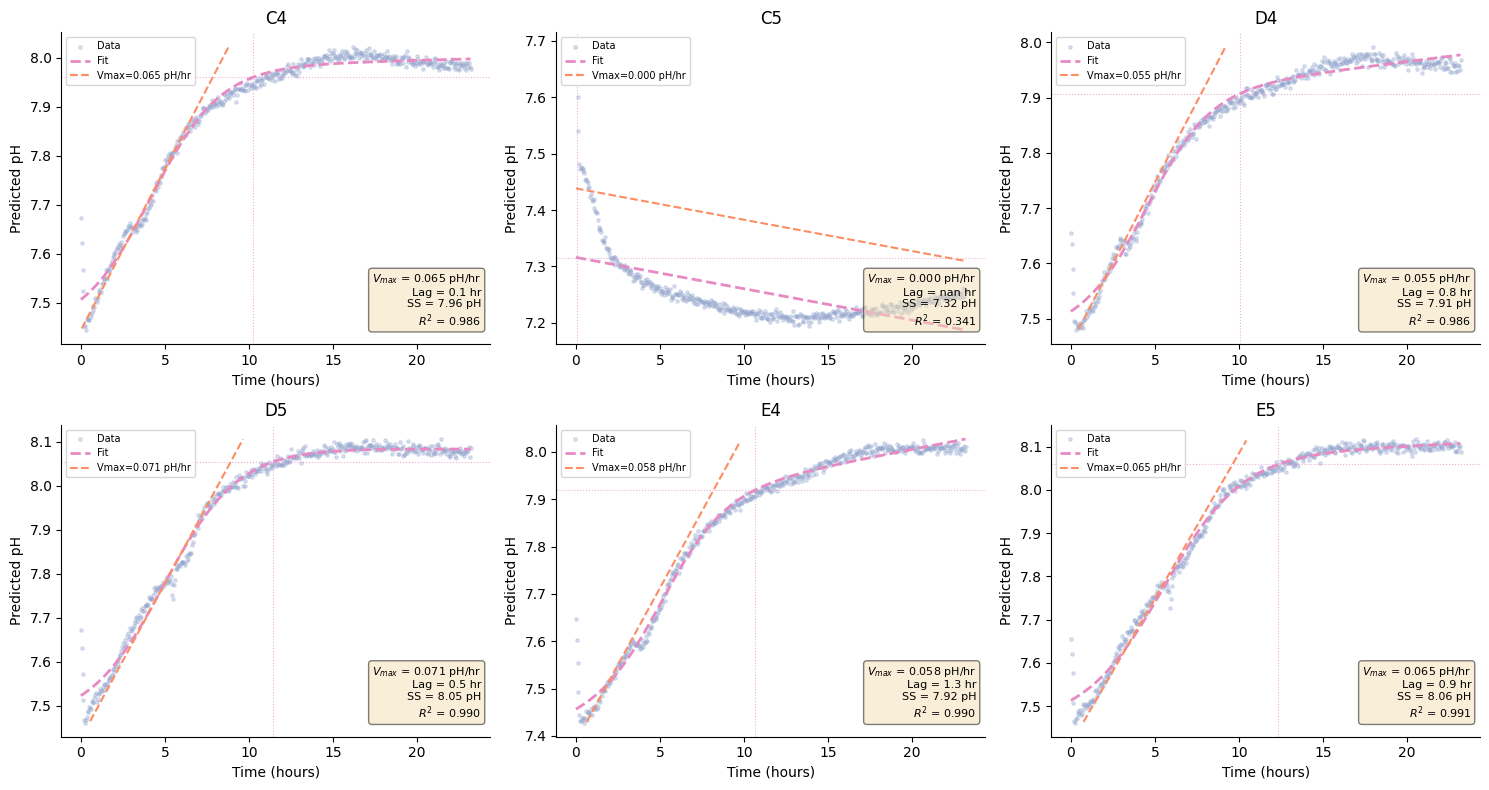

In [11]:
# Per-well kinetics grid with annotations
phc.plot_kinetics_grid(kinetic, fit.slope, fit.intercept, kin);

In [13]:
kin.head()

,vmax,vmax_time_hr,vmax_pH,lag_time_hr,lag_pH,steady_state_time_hr,steady_state_pH,fit_params,fit_offset,r_squared,drift,fit_type
well,,,,,,,,,,,,
C4,0.064854,4.168783,7.714071,0.057640,7.507462,10.221288,7.959259,"[0.5332453262704515, 0.4864827085278614, 4.168...",7.443848,0.985825,0.000864,sigmoid_drift
C5,0.000000,0.000000,7.316059,NaN,NaN,0.059312,7.315730,"[0.0, 49.64361966496037, 0.0, -0.0055466981561...",7.193806,0.340863,-0.005547,sigmoid_drift
D4,0.054584,4.527465,7.701737,0.770210,7.531318,10.058968,7.907260,"[0.4101738095923647, 0.532303556105549, 4.5274...",7.479508,0.986302,0.003786,sigmoid_drift
D5,0.070522,4.924227,7.773698,0.493633,7.536464,11.447034,8.053834,"[0.6249065499429097, 0.4514067352732618, 4.924...",7.462054,0.989683,-0.000164,sigmoid_drift
E4,0.057984,5.092224,7.683177,1.293998,7.489488,10.684046,7.919606,"[0.4404740599063328, 0.5265616537764595, 5.092...",7.428138,0.990213,0.006834,sigmoid_drift


In [12]:
kin_reindex = kin.reset_index()
kin_reindex["good_fit"] = kin_reindex['r_squared'] > 0.96
kin_reindex

,well,vmax,vmax_time_hr,vmax_pH,lag_time_hr,lag_pH,steady_state_time_hr,steady_state_pH,fit_params,fit_offset,r_squared,drift,fit_type,good_fit
0,C4,0.064854,4.168783,7.714071,0.057640,7.507462,10.221288,7.959259,"[0.5332453262704515, 0.4864827085278614, 4.168...",7.443848,0.985825,0.000864,sigmoid_drift,True
1,C5,0.000000,0.000000,7.316059,NaN,NaN,0.059312,7.315730,"[0.0, 49.64361966496037, 0.0, -0.0055466981561...",7.193806,0.340863,-0.005547,sigmoid_drift,False
2,D4,0.054584,4.527465,7.701737,0.770210,7.531318,10.058968,7.907260,"[0.4101738095923647, 0.532303556105549, 4.5274...",7.479508,0.986302,0.003786,sigmoid_drift,True
3,D5,0.070522,4.924227,7.773698,0.493633,7.536464,11.447034,8.053834,"[0.6249065499429097, 0.4514067352732618, 4.924...",7.462054,0.989683,-0.000164,sigmoid_drift,True
4,E4,0.057984,5.092224,7.683177,1.293998,7.489488,10.684046,7.919606,"[0.4404740599063328, 0.5265616537764595, 5.092...",7.428138,0.990213,0.006834,sigmoid_drift,True
5,E5,0.065402,5.523260,7.774678,0.889894,7.536029,12.344593,8.058981,"[0.6060586560328652, 0.4316515990215163, 5.523...",7.462274,0.991435,0.001697,sigmoid_drift,True


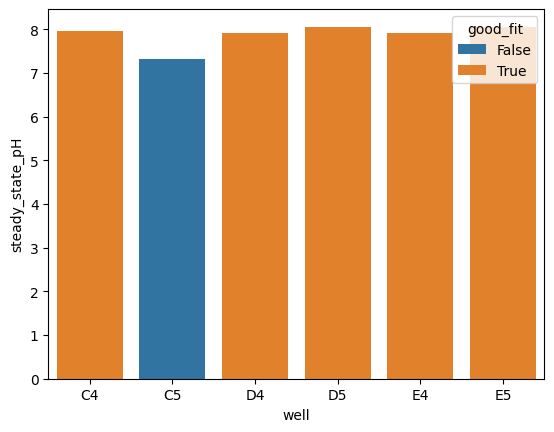

In [14]:
import seaborn as sns
_ = sns.barplot(kin_reindex, x="well", y="steady_state_pH", hue="good_fit")

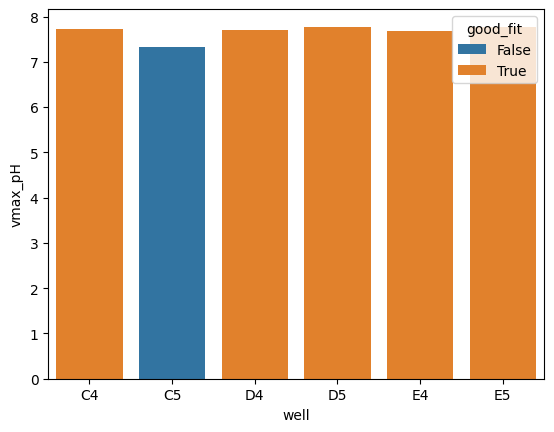

In [15]:
_ = sns.barplot(kin_reindex, x="well", y="vmax_pH", hue="good_fit")